<a href="https://colab.research.google.com/github/goija/vortexarcheologie_v72/blob/main/ELSmapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

In [3]:
X = 7   # columns
Y = 13  # rows
N = X * Y

grid = np.arange(1, N+1).reshape(Y, X)  # row-major: 1..7 top row, etc.
grid


array([[ 1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19, 20, 21],
       [22, 23, 24, 25, 26, 27, 28],
       [29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42],
       [43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56],
       [57, 58, 59, 60, 61, 62, 63],
       [64, 65, 66, 67, 68, 69, 70],
       [71, 72, 73, 74, 75, 76, 77],
       [78, 79, 80, 81, 82, 83, 84],
       [85, 86, 87, 88, 89, 90, 91]])

In [4]:
def idx_to_rc(i, X):
    """1-based index -> (row, col) 0-based."""
    i0 = i - 1
    return i0 // X, i0 % X

def rc_to_idx(r, c, X):
    """(row, col) 0-based -> 1-based index."""
    return r * X + c + 1


In [5]:
def els_linear(start, D, N):
    """
    ELS as linear trajectory in 1..N:
    start, start+D, start+2D, ... while <= N
    """
    seq = []
    k = 0
    while True:
        v = start + k * D
        if v < 1 or v > N:
            break
        seq.append(v)
        k += 1
    return seq

# Jouw voorbeelden
seq_D7 = els_linear(1, 7, N)
seq_D8 = els_linear(1, 8, N)
seq_D6 = els_linear(7, 6, N)

seq_D7, seq_D8, seq_D6[:10], len(seq_D6)


([1, 8, 15, 22, 29, 36, 43, 50, 57, 64, 71, 78, 85],
 [1, 9, 17, 25, 33, 41, 49, 57, 65, 73, 81, 89],
 [7, 13, 19, 25, 31, 37, 43, 49, 55, 61],
 15)

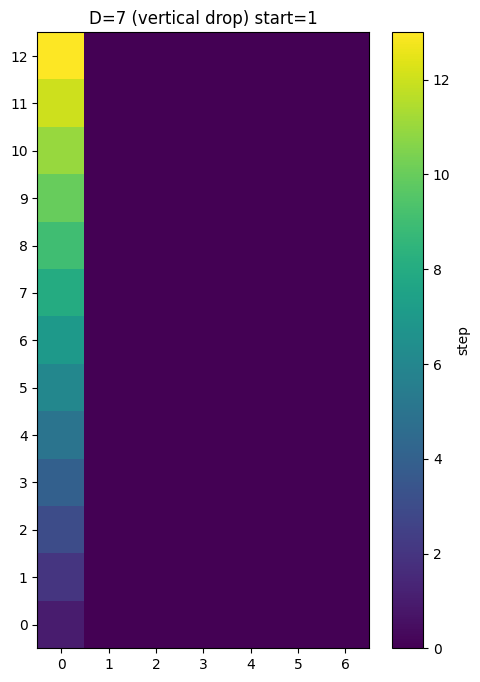

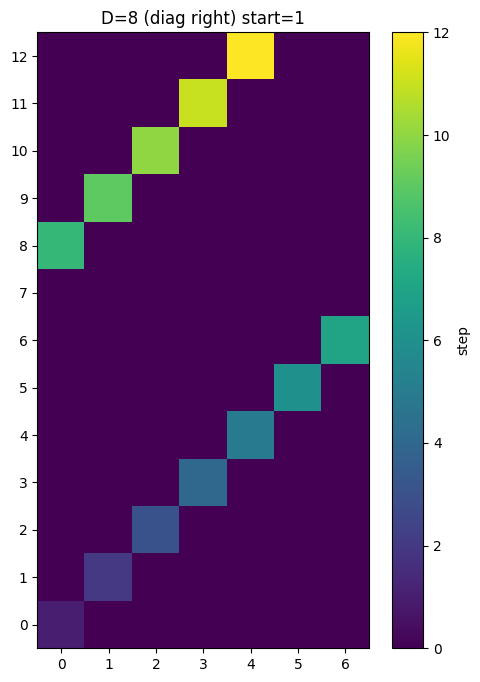

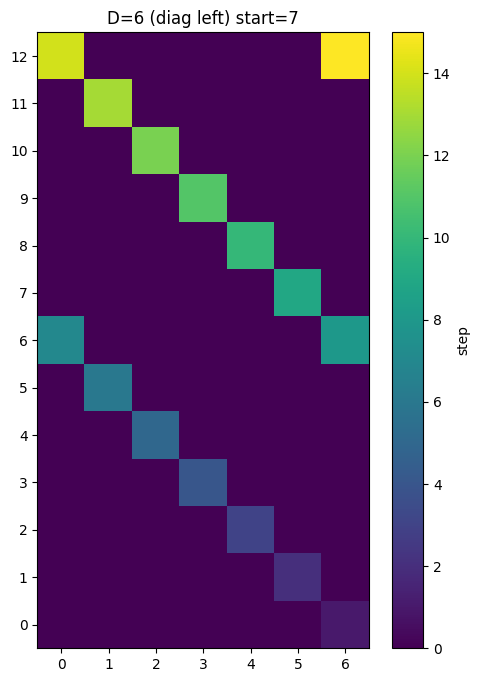

In [6]:
def plot_path(seq, X, Y, title="ELS path"):
    img = np.zeros((Y, X), dtype=float)

    for t, i in enumerate(seq):
        r, c = idx_to_rc(i, X)
        img[r, c] = t + 1  # step number

    plt.figure(figsize=(6, 8))
    plt.imshow(img, cmap="viridis", interpolation="nearest")
    plt.colorbar(label="step")
    plt.title(title)
    plt.xticks(range(X))
    plt.yticks(range(Y))
    plt.gca().invert_yaxis()  # top row as row 0 visually
    plt.show()

plot_path(seq_D7, X, Y, "D=7 (vertical drop) start=1")
plot_path(seq_D8, X, Y, "D=8 (diag right) start=1")
plot_path(seq_D6, X, Y, "D=6 (diag left) start=7")


In [22]:
correlation_matrix = df_freqs.corr()
display(correlation_matrix)

,D=7 (vertical drop),D=8 (diag right),D=6 (diag left)
D=7 (vertical drop),1.000000,0.972167,0.940907
D=8 (diag right),0.972167,1.000000,0.844341
D=6 (diag left),0.940907,0.844341,1.000000


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
mean_data = {
    'Pad': ['D=7 (verticale drop)', 'D=8 (diagonaal rechts)', 'D=6 (diagonaal links)'],
    'Gemiddelde Frequentie': [mean_freqs7, mean_freqs8, mean_freqs6]
}
df_means = pd.DataFrame(mean_data)

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(df_means['Pad'], df_means['Gemiddelde Frequentie'], color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Gemiddelde Frequenties van de Paden')
plt.xlabel('Frequentiepad')
plt.ylabel('Gemiddelde Frequentie (Hz)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
import pandas as pd

# Combine frequencies into a DataFrame (if not already done)
data_for_summary = {
    'D=7 (vertical drop)': freqs7,
    'D=8 (diag right)': freqs8,
    'D=6 (diag left)': freqs6
}

df_freqs_summary = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_for_summary.items()]))

# Bereken en toon de samenvattende statistieken
summary_statistics = df_freqs_summary.describe()
display(summary_statistics)

,D=7 (vertical drop),D=8 (diag right),D=6 (diag left)
count,13.000000,12.000000,15.000000
mean,380.739569,533.903102,293.939271
std,246.684843,386.839397,204.494265
min,110.000000,110.000000,110.000000
25%,184.997211,245.218603,134.702049
50%,311.126984,453.081881,311.126984
75%,523.251131,662.688194,380.994929
max,880.000000,1396.912926,880.000000


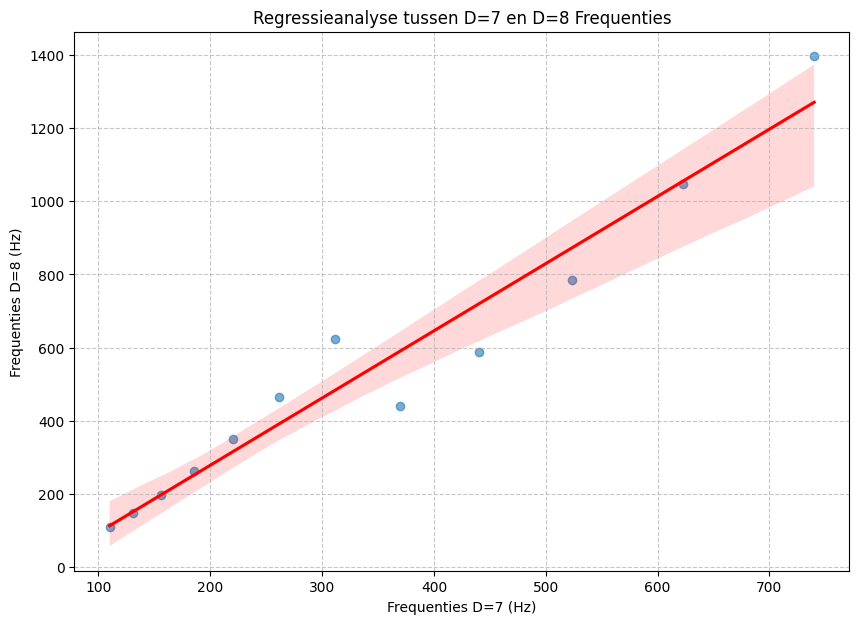

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Om te zorgen dat beide lijsten even lang zijn voor de scatterplot,
# zullen we de langste inkorten tot de lengte van de kortste.
# In dit geval heeft freqs7 13 elementen en freqs8 12 elementen.
min_len = min(len(freqs7), len(freqs8))

data_for_regplot = pd.DataFrame({
    'D=7 Frequencies': freqs7[:min_len],
    'D=8 Frequencies': freqs8[:min_len]
})

plt.figure(figsize=(10, 7))
sns.regplot(x='D=7 Frequencies', y='D=8 Frequencies', data=data_for_regplot, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regressieanalyse tussen D=7 en D=8 Frequenties')
plt.xlabel('Frequenties D=7 (Hz)')
plt.ylabel('Frequenties D=8 (Hz)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
from scipy import stats

# Voer een onafhankelijke t-test uit
t_statistic, p_value = stats.ttest_ind(freqs7, freqs8)

print(f"T-statistiek: {t_statistic:.2f}")
print(f"P-waarde: {p_value:.3f}")

# Interpretatie van de p-waarde
alpha = 0.05  # Significantieniveau

if p_value < alpha:
    print("Er is een significant verschil tussen de gemiddelde frequenties van D=7 en D=8 (p < 0.05).")
else:
    print("Er is geen significant verschil tussen de gemiddelde frequenties van D=7 en D=8 (p >= 0.05).")

T-statistiek: -1.19
P-waarde: 0.246
Er is geen significant verschil tussen de gemiddelde frequenties van D=7 en D=8 (p >= 0.05).


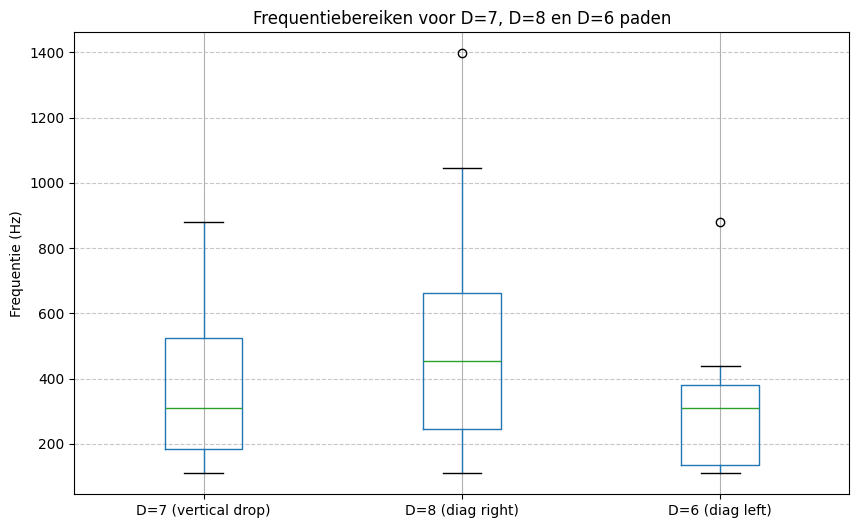

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine frequencies into a DataFrame for easier plotting
data_for_boxplot = {
    'D=7 (vertical drop)': freqs7,
    'D=8 (diag right)': freqs8,
    'D=6 (diag left)': freqs6
}

df_freqs = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_for_boxplot.items()]))

plt.figure(figsize=(10, 6))
df_freqs.boxplot()
plt.title('Frequentiebereiken voor D=7, D=8 en D=6 paden')
plt.ylabel('Frequentie (Hz)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

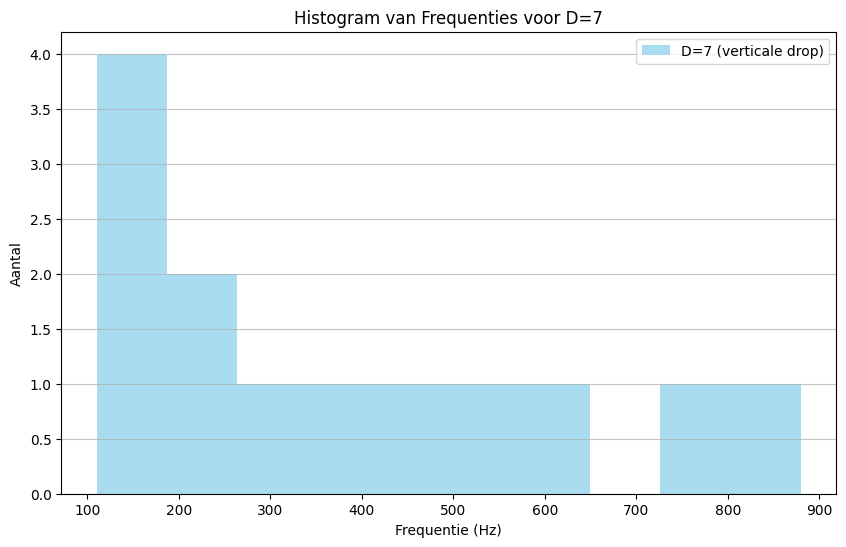

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(freqs7, bins=10, alpha=0.7, label='D=7 (verticale drop)', color='skyblue')
plt.title('Histogram van Frequenties voor D=7')
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Aantal')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

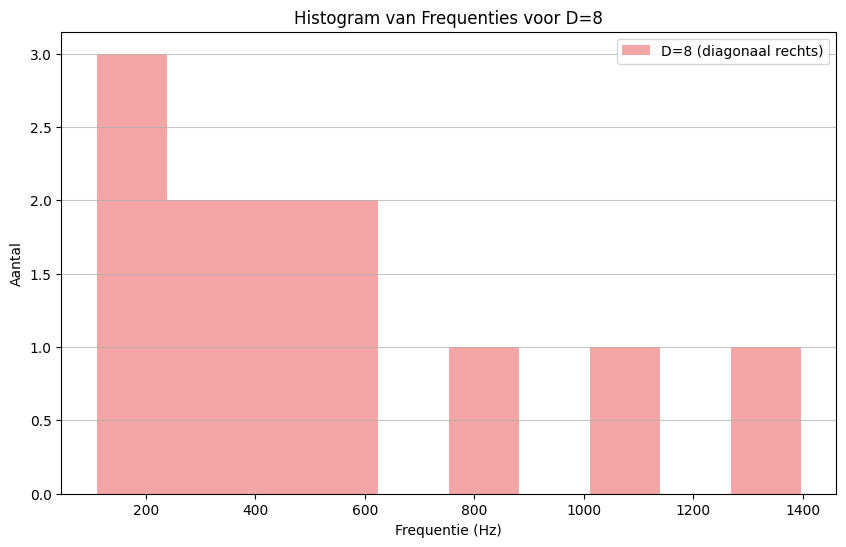

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(freqs8, bins=10, alpha=0.7, label='D=8 (diagonaal rechts)', color='lightcoral')
plt.title('Histogram van Frequenties voor D=8')
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Aantal')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

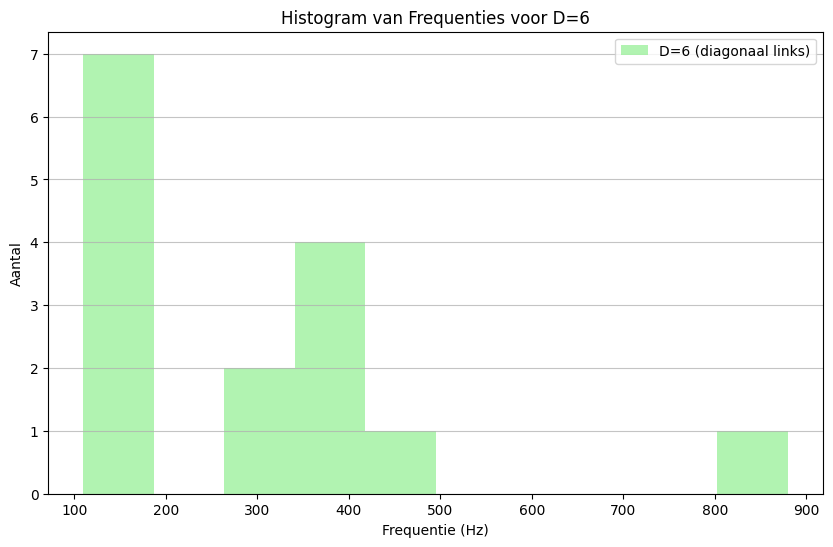

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(freqs6, bins=10, alpha=0.7, label='D=6 (diagonaal links)', color='lightgreen')
plt.title('Histogram van Frequenties voor D=6')
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Aantal')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

In [24]:
import numpy as np

def find_outliers_iqr(data, name):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    print(f"Uitschieters voor {name}:")
    if outliers:
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Ondergrens: {lower_bound:.2f}, Bovengrens: {upper_bound:.2f}")
        print(f"  Gevonden uitschieters: {outliers}\n")
    else:
        print("  Geen uitschieters gevonden.\n")


find_outliers_iqr(freqs7, 'D=7 (verticale drop)')
find_outliers_iqr(freqs8, 'D=8 (diagonaal rechts)')
find_outliers_iqr(freqs6, 'D=6 (diagonaal links)')

Uitschieters voor D=7 (verticale drop):
  Geen uitschieters gevonden.

Uitschieters voor D=8 (diagonaal rechts):
  Q1: 245.22, Q3: 662.69, IQR: 417.47
  Ondergrens: -380.99, Bovengrens: 1288.89
  Gevonden uitschieters: [1396.9129257320155]

Uitschieters voor D=6 (diagonaal links):
  Q1: 134.70, Q3: 380.99, IQR: 246.29
  Ondergrens: -234.74, Bovengrens: 750.43
  Gevonden uitschieters: [880.0]



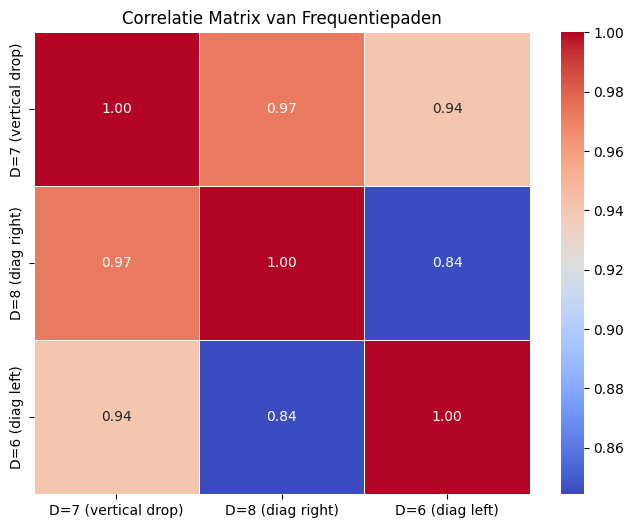

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlatie Matrix van Frequentiepaden')
plt.show()

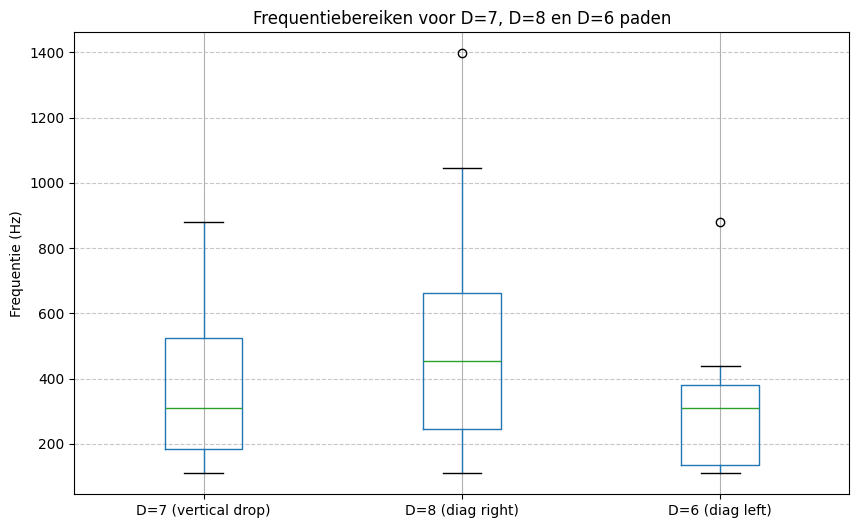

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine frequencies into a DataFrame for easier plotting
data_for_boxplot = {
    'D=7 (vertical drop)': freqs7,
    'D=8 (diag right)': freqs8,
    'D=6 (diag left)': freqs6
}

df_freqs = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_for_boxplot.items()]))

plt.figure(figsize=(10, 6))
df_freqs.boxplot()
plt.title('Frequentiebereiken voor D=7, D=8 en D=6 paden')
plt.ylabel('Frequentie (Hz)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
import numpy as np

# Calculate for freqs7
mean_freqs7 = np.mean(freqs7)
std_freqs7 = np.std(freqs7)
print(f"Frequentiepad D=7 (verticale drop):")
print(f"  Gemiddelde frequentie: {mean_freqs7:.2f} Hz")
print(f"  Standaarddeviatie frequentie: {std_freqs7:.2f} Hz\n")

# Calculate for freqs8
mean_freqs8 = np.mean(freqs8)
std_freqs8 = np.std(freqs8)
print(f"Frequentiepad D=8 (diagonaal rechts):")
print(f"  Gemiddelde frequentie: {mean_freqs8:.2f} Hz")
print(f"  Standaarddeviatie frequentie: {std_freqs8:.2f} Hz\n")

# Calculate for freqs6
mean_freqs6 = np.mean(freqs6)
std_freqs6 = np.std(freqs6)
print(f"Frequentiepad D=6 (diagonaal links):")
print(f"  Gemiddelde frequentie: {mean_freqs6:.2f} Hz")
print(f"  Standaarddeviatie frequentie: {std_freqs6:.2f} Hz")

Frequentiepad D=7 (verticale drop):
  Gemiddelde frequentie: 380.74 Hz
  Standaarddeviatie frequentie: 237.01 Hz

Frequentiepad D=8 (diagonaal rechts):
  Gemiddelde frequentie: 533.90 Hz
  Standaarddeviatie frequentie: 370.37 Hz

Frequentiepad D=6 (diagonaal links):
  Gemiddelde frequentie: 293.94 Hz
  Standaarddeviatie frequentie: 197.56 Hz


In [12]:
BASE_F0 = 110.0

def path_to_semitones(seq, X):
    """
    Convert step-to-step movement to semitone offsets.
    Rule (simple + deterministic):
      dr, dc computed from grid positions:
      semitone = 2*dc + 3*dr
    """
    semis = [0]
    for a, b in zip(seq, seq[1:]):
        ra, ca = idx_to_rc(a, X)
        rb, cb = idx_to_rc(b, X)
        dr = rb - ra
        dc = cb - ca
        semis.append(semis[-1] + (2*dc + 3*dr))
    return semis

def semitones_to_freqs(semis, f0=BASE_F0):
    return [f0 * (2 ** (s/12)) for s in semis]

semis7 = path_to_semitones(seq_D7, X)
freqs7 = semitones_to_freqs(semis7)

semis8 = path_to_semitones(seq_D8, X)
freqs8 = semitones_to_freqs(semis8)

semis6 = path_to_semitones(seq_D6, X)
freqs6 = semitones_to_freqs(semis6)

freqs7[:5], freqs8[:5], freqs6[:5]


([110.0, 130.8127826502993, 155.56349186104046, 184.9972113558172, 220.0],
 [110.0,
  146.8323839587038,
  195.99771799087463,
  261.6255653005986,
  349.2282314330039],
 [110.0,
  116.54094037952248,
  123.47082531403103,
  130.8127826502993,
  138.59131548843604])

In [13]:
# https://colab.research.google.com/github/<USER>/<REPO>/blob/main/notebooks/ELS_Vortex_91.ipynb

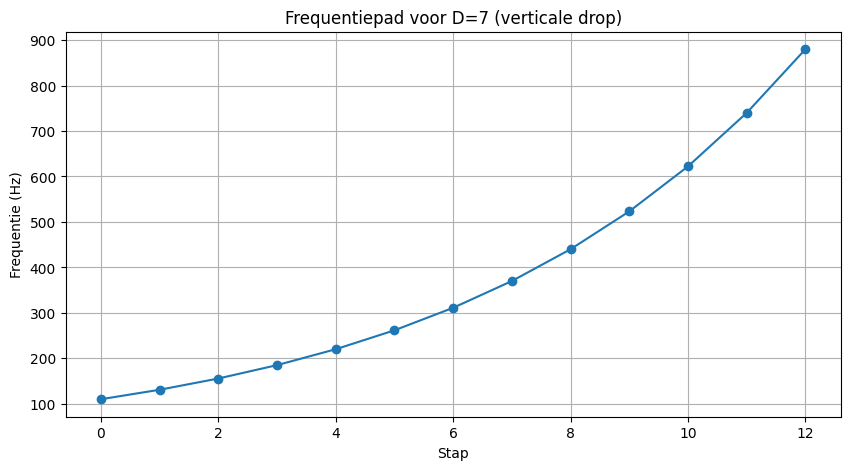

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(freqs7, marker='o')
plt.title('Frequentiepad voor D=7 (verticale drop)')
plt.xlabel('Stap')
plt.ylabel('Frequentie (Hz)')
plt.grid(True)
plt.show()

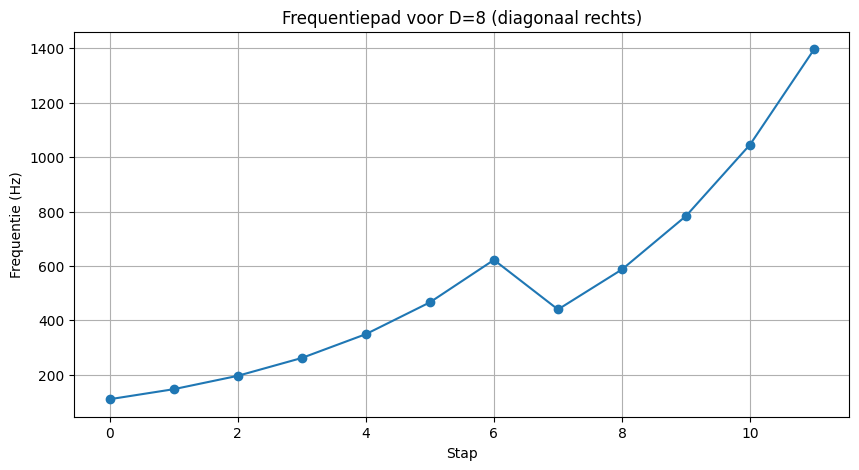

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(freqs8, marker='o')
plt.title('Frequentiepad voor D=8 (diagonaal rechts)')
plt.xlabel('Stap')
plt.ylabel('Frequentie (Hz)')
plt.grid(True)
plt.show()

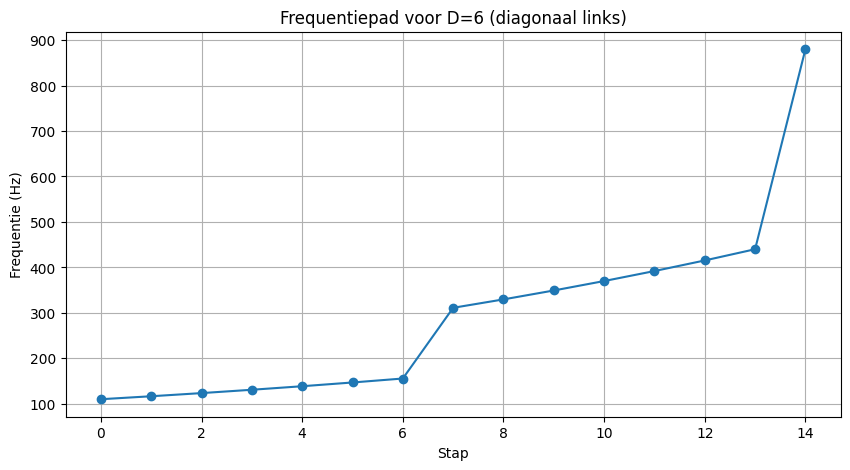

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(freqs6, marker='o')
plt.title('Frequentiepad voor D=6 (diagonaal links)')
plt.xlabel('Stap')
plt.ylabel('Frequentie (Hz)')
plt.grid(True)
plt.show()